In [ ]:
from highway_extension.highway import ContinuousHighwayEnvironment, ContinuousHighwayEnvironmentConfig, HighwayReward
import torch
env = ContinuousHighwayEnvironment(
    config=ContinuousHighwayEnvironmentConfig(),
        reward=HighwayReward()
)




In [ ]:
torch.set_printoptions(precision=2, sci_mode=False)
env.reset()
from IPython.display import display, clear_output
for i in range(100):
    clear_output(wait=True)
    action = torch.tensor(env.action_space.sample())
    obs, reward, terminated, truncated, info = env.step(action)
    display(obs.reshape((1,16,14))[0,:,0:7])
    display(reward)
    if terminated.abs() >0:
        print("Terminated")
        break


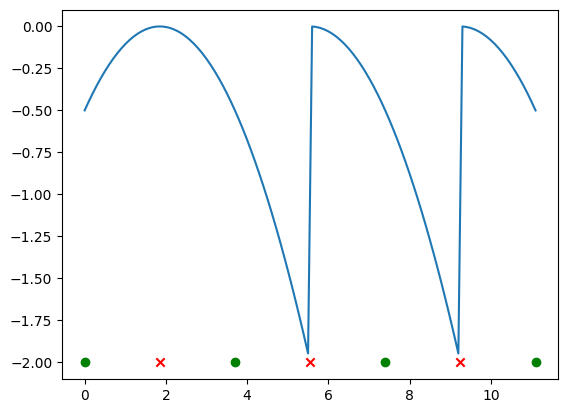

In [6]:
import torch
torch.set_printoptions(precision=2, sci_mode=False)
from torch import Tensor, no_grad, minimum
x = torch.arange(0,3.7*3,0.1).reshape(-1,1)

obs = torch.zeros((x.shape[0],7))

obs[:,2:3] = x/12

def _lane_keep_reward( obs_ego: Tensor) -> Tensor:
    """
    车道保持: 对横向偏移做稠密惩罚, 让车保持在车道中心附近.

    Args:
        obs_ego (Tensor): 自车状态, shape = (B, 7)

    Returns:
        reward (Tensor): 奖励(越高越好, 正值), shape = (B,1)
    """
    y_position = obs_ego[:, 2]*12 # 真实世界坐标, shape = (B,1)

    lane_index = ((y_position-3.7/2)/3.7).int()
    nearest_lane_center = (lane_index+0.5)*3.7
    lateral_offset = y_position - nearest_lane_center
    reward = -2.0 * minimum((lateral_offset/3.7)**2,torch.ones_like(lateral_offset)*4.0)

    return reward.reshape(-1,1)

y  = _lane_keep_reward(obs)

import matplotlib.pyplot as plt
plt.plot(x.numpy(),y.numpy())
plt.scatter([3.7*0.5,3.7*1.5,3.7*2.5],[-2,-2,-2],c='r',marker='x')
plt.scatter([0,3.7,3.7*2,3.7*3],[-2,-2,-2,-2],c='g',marker='o')